In [123]:
import numpy as np
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/Colab Notebooks/optimisatio"
df = pd.read_csv('student_habits_performance.csv')
df.head(5)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/optimisatio


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [124]:
# Vérification de la taille du dataset
print(f"Le jeu de données a {df.shape[0]} individus et {df.shape[1]} valiables")

Le jeu de données a 1000 individus et 16 valiables


In [125]:
# Vérification du type de chaque variable
df.dtypes

,0
student_id,object
age,int64
gender,object
study_hours_per_day,float64
social_media_hours,float64
netflix_hours,float64
part_time_job,object
attendance_percentage,float64
sleep_hours,float64
diet_quality,object


In [126]:
# Statistique descriptive
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [127]:
# Vérification des valeurs manquantes

df_manque = df.isnull().sum()
df_manque[df_manque > 0]

,0
parental_education_level,91


In [128]:
# Imputation de la variable parental_education_level par le mode
df['parental_education_level'] = df['parental_education_level'].fillna(df['parental_education_level'].mode()[0])

In [129]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


In [130]:
# Doublon
df.duplicated().sum()

np.int64(0)

In [131]:
X = df.drop(['student_id', 'exam_score'], axis=1)
y = df.exam_score

In [132]:
for col in ['gender', 'part_time_job', 'extracurricular_participation',
            'diet_quality', 'parental_education_level', 'internet_quality']:
    print(f"{col} : {df[col].unique()}")

gender : ['Female' 'Male' 'Other']
part_time_job : ['No' 'Yes']
extracurricular_participation : ['Yes' 'No']
diet_quality : ['Fair' 'Good' 'Poor']
parental_education_level : ['Master' 'High School' 'Bachelor']
internet_quality : ['Average' 'Poor' 'Good']


In [133]:
# Encodage des variables ordinales
diet_map = {'Poor': 0, 'Fair': 1, 'Good': 2}
X['diet_quality'] = X['diet_quality'].map(diet_map)

education_map = {'High School': 0, 'Bachelor': 1, 'Master': 2}
X['parental_education_level'] = X['parental_education_level'].map(education_map)

internet_map = {'Poor': 0, 'Average': 1, 'Good': 2}
X['internet_quality'] = X['internet_quality'].map(internet_map)

# Encodage des variables nominales
gender_map = {'Female': 0, 'Male': 1, 'Other': 2}
X['gender'] = X['gender'].map(gender_map)

job_map = {'No': 0, 'Yes': 1}
X['part_time_job'] = X['part_time_job'].map(job_map)

extra_map = {'No': 0, 'Yes': 1}
X['extracurricular_participation'] = X['extracurricular_participation'].map(extra_map)

In [134]:
X.head()

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation
0,23,0,0.0,1.2,1.1,0,85.0,8.0,1,6,2,1,8,1
1,20,0,6.9,2.8,2.3,0,97.3,4.6,2,6,0,1,8,0
2,21,1,1.4,3.1,1.3,0,94.8,8.0,0,1,0,0,1,0
3,23,0,1.0,3.9,1.0,0,71.0,9.2,0,4,2,2,1,1
4,19,0,5.0,4.4,0.5,0,90.9,4.9,1,3,2,2,1,0


In [135]:
# Normalisation
mean = X.mean()
std = X.std()

X_scaled = (X - mean) / std
print(X_scaled.describe().round(2))

           age   gender  study_hours_per_day  social_media_hours  \
count  1000.00  1000.00              1000.00             1000.00   
mean     -0.00    -0.00                -0.00               -0.00   
std       1.00     1.00                 1.00                1.00   
min      -1.52    -0.98                -2.42               -2.14   
25%      -0.76    -0.98                -0.65               -0.69   
50%      -0.22     0.76                -0.03               -0.00   
75%       1.08     0.76                 0.65                0.68   
max       1.52     2.50                 3.23                4.00   

       netflix_hours  part_time_job  attendance_percentage  sleep_hours  \
count        1000.00        1000.00                1000.00      1000.00   
mean           -0.00          -0.00                   0.00        -0.00   
std             1.00           1.00                   1.00         1.00   
min            -1.69          -0.52                  -2.99        -2.67   
25%         

In [136]:
# Conversion en listes Python
X_tab = X_scaled.values.tolist()
y_tab = y.values.tolist()

X_b = X_tab





In [137]:
# Implémentation de la régression linéaire
def regression_lineaire(X, w, b):
    y_pred = []
    for i in range(len(X)):
        val = 0
        for j in range(len(w)):
            val += w[j] * X[i][j]
        val += b
        y_pred.append(val)
    return y_pred

In [138]:
# Fonction MSE
def mse(y_attendu, y_pred):
    m = len(y_attendu)
    sum = 0
    for i in range(m):
        sum += (y_attendu[i] - y_pred[i])**2
    return sum / m

In [139]:
# Dérivées partielles
def derivee_w(X, y_true, w, y_pred):
    m = len(y_true)
    grads = []

    for j in range(len(w)):
        deriv_w = 0
        for i in range(m):
            deriv_w += (y_pred[i] - y_true[i]) * X[i][j]
        grads.append((2/m) * deriv_w)

    return grads

def derivee_b(y_true, y_pred):
    m = len(y_true)
    grad_b = 0

    for i in range(m):
        grad_b += (y_pred[i] - y_true[i])

    return (2/m) * grad_b


In [140]:
def r2_score(y_true, y_pred):
    y_mean = sum(y_true) / len(y_true)

    ss_total = 0
    ss_res = 0

    for i in range(len(y_true)):
        ss_total += (y_true[i] - y_mean) ** 2
        ss_res += (y_true[i] - y_pred[i]) ** 2

    return 1 - (ss_res / ss_total)

In [141]:
import random
random.seed(42)
data = list(zip(X_tab, y_tab))
random.shuffle(data)

In [142]:
split_ratio = 0.8
split_index = int(len(data) * split_ratio)

train_data = data[:split_index]
test_data = data[split_index:]

In [143]:
X_train = [x for x, y in train_data]
y_train = [y for x, y in train_data]

X_test = [x for x, y in test_data]
y_test = [y for x, y in test_data]

In [144]:
# Gradient Descent
# Initialiser les poids à 0
w = [0] * len(X_train[0])
b = 0
alpha = 0.01
n_iter = 2000
list_cout = []


for i in range(n_iter):
    y_pred = regression_lineaire(X_train, w, b)

    #  Coût
    cout = mse(y_train, y_pred)
    list_cout.append(cout)

    dw = derivee_w(X_train, y_train, w, y_pred)
    db = derivee_b(y_train, y_pred)

    for j in range(len(w)):
        w[j] -= alpha * dw[j]

    b -= alpha * db



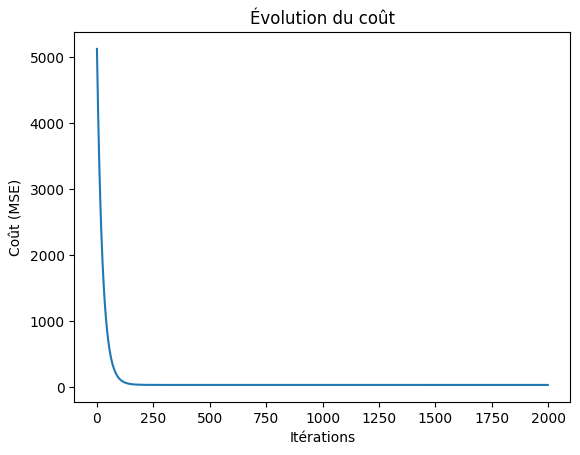

In [145]:

plt.plot(range(n_iter), list_cout)
plt.xlabel("Itérations")
plt.ylabel("Coût (MSE)")
plt.title("Évolution du coût")
plt.show()

In [146]:
y_pred_test = regression_lineaire(X_test, w, b)

print("MSE test :", mse(y_test, y_pred_test))
print("R² test :", r2_score(y_test, y_pred_test))

MSE test : 26.882072053607722
R² test : 0.8959957734222165


In [147]:
y_pred_train = regression_lineaire(X_train, w, b)

print("R² train :", r2_score(y_train, y_pred_train))
print("R² test :", r2_score(y_test, y_pred_test))

R² train : 0.9019549782573529
R² test : 0.8959957734222165


In [148]:
importance = []

for i in range(len(w)):
    importance.append((colonnes[i], abs(w[i])))

# trier du plus important au moins important
importance.sort(key=lambda x: x[1], reverse=True)

for col, val in importance:
    print(col, val)

print(f"Biais : {b:.4f}")

study_hours_per_day 13.987065526560725
mental_health_rating 5.412096704939873
exercise_frequency 3.074436675496435
social_media_hours 3.0315862968254943
netflix_hours 2.4967418406510693
sleep_hours 2.4849229422632075
attendance_percentage 1.2537327812626573
extracurricular_participation 0.19079631203287756
internet_quality 0.18865958290693008
parental_education_level 0.1320298760270546
part_time_job 0.12831069864302402
gender 0.05281357689960492
diet_quality 0.04300710227379791
age 0.0036284328830057987
Biais : 69.5175
